In [84]:
#I started working on this chapter already but I cant find the file so I'm taking it from the top
#Moving forward, I will create a folder that stores all relevant files to this book
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC, SVR
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from io import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
from sklearn import tree


In [2]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()
df_iris_features = pd.DataFrame(data=iris_dataset.data, columns=iris_dataset.feature_names)
df_iris_target = pd.DataFrame(data=iris_dataset.target, columns=['class'])
df_iris_features.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
df_iris_target.head()

,class
0,0
1,0
2,0
3,0
4,0


In [4]:
#Split the dataset
iris_split = train_test_split(
    df_iris_features,
    df_iris_target,
    test_size = 0.25,
    random_state = 17
)
df_iris_features_train = iris_split[0]
df_iris_features_test = iris_split[1]
df_iris_target_train = iris_split[2]
df_iris_target_test = iris_split[3]

In [5]:
#Now lets stratify the dataset
iris_split_strat = train_test_split(
    df_iris_features,
    df_iris_target,
    test_size = 0.25,
    random_state = 17,
    stratify = df_iris_target
)
df_iris_features_train2 = iris_split_strat[0]
df_iris_features_test2 = iris_split_strat[1]
df_iris_target_train2 = iris_split_strat[2]
df_iris_target_test2 = iris_split_strat[3]

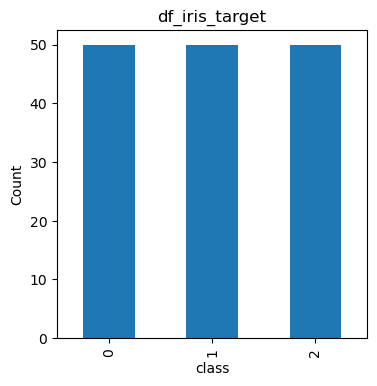

In [6]:
#Now let's create some visuals
#We can plot the original train_test_split vs the stratisfied one
def embarked_bar_chart(df,title,size_h,size_w):

    fig, ax = plt.subplots(figsize=(size_h,size_w))
    ax.grid()
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.set_title(title)
    df.value_counts(dropna=True).plot.bar()

embarked_bar_chart(df_iris_target['class'],'df_iris_target',4,4)

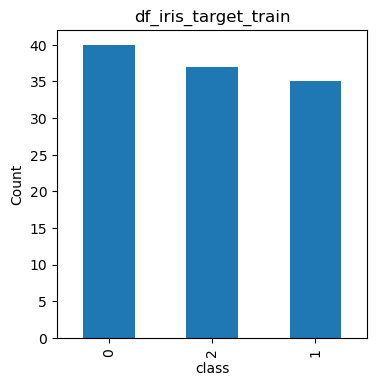

In [7]:
embarked_bar_chart(df_iris_target_train['class'],'df_iris_target_train', 4,4)

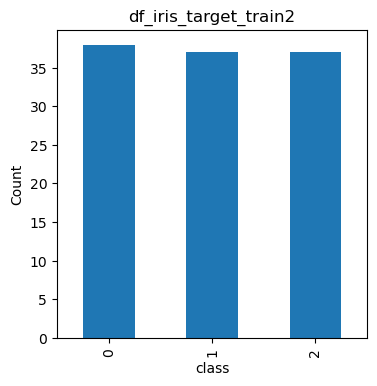

In [8]:
embarked_bar_chart(df_iris_target_train2['class'],'df_iris_target_train2', 4,4)

K-Fold validation

The main drawback of splitting the training dataset into into a training and validation set is that it's possible for samples in the training set to exhibit characteristics that may not be found in the samples of the validation/test set. 

How it works:

1.Choose a value of k

2.Shuffle the data

3.Split the data into equal k subsets:

4.For each value of k: 
    a.Train a model that uses the kth subset as the test set and the samples of the k-1 subset as the training set.
    b. Record the performance of the model when making predictions on the kth subset.
5.Compute the mean performance of the individual models to work out the overall performance. 
If it gets confusing look back at pg 85 on figure 4.4

In [9]:
#Now we are going to use kfold on the Iris dataset
#perform 10-fold split on the Iris dataset
from sklearn.model_selection import KFold
kf = KFold(n_splits=10,shuffle=True, random_state=32)

fold_number = 1
for train_indices, test_indices in kf.split(df_iris_features):
    print("Fold Number:", fold_number)
    print("Training Indices:", train_indices)
    print("Test Indices:", test_indices)

    fold_number = fold_number + 1

    df_iris_features_train = df_iris_features.iloc[train_indices]
    df_iris_target_train = df_iris_target.iloc[train_indices]

    df_iris_features_test = df_iris_features.iloc[test_indices]
    df_iris_target_test = df_iris_target.iloc[test_indices]

Fold Number: 1
Training Indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  24  25  27  28  29  30  31  32  33  35  36  37  38  39  40
  41  42  43  44  45  46  47  48  49  50  51  52  53  54  57  58  59  61
  62  63  64  65  66  68  69  70  71  72  73  74  75  77  78  79  80  81
  82  83  84  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100
 101 102 103 104 105 106 107 108 109 110 111 112 113 114 116 117 118 119
 120 121 122 123 124 125 126 127 128 129 130 132 133 135 136 137 138 139
 140 141 142 143 144 145 146 148 149]
Test Indices: [ 21  22  23  26  34  55  56  60  67  76  85 115 131 134 147]
Fold Number: 2
Training Indices: [  0   1   2   3   4   5   6   7   8   9  11  14  15  17  18  19  20  21
  22  23  24  25  26  28  29  30  31  32  33  34  35  36  37  38  40  41
  42  43  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60
  61  62  63  64  65  67  68  70  71  72  73  74  75  76  77  78  79  80
  81  82  83  84 

In [10]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
california_housing_features = pd.DataFrame(data=housing.data, columns=housing.feature_names)
california_housing_features.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [11]:
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

# Analyze the printed information about this dataset so I can better understand my results

In [12]:
california_housing_target = pd.DataFrame(data=housing.target,columns=['price'])

In [13]:
california_housing_target.head()

,price
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [14]:
california_housing_split = train_test_split(
    california_housing_features,
    california_housing_target,
    test_size=0.25,
    random_state=17
)

california_housing_features_train = california_housing_split[0]
california_housing_features_test = california_housing_split[1]
california_housing_target_train = california_housing_split[2]
california_housing_target_test = california_housing_split[3]

In [15]:
linear_regression_model = LinearRegression(fit_intercept=True)
linear_regression_model.fit(
    california_housing_features,
    california_housing_target
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
print(linear_regression_model.coef_),print(linear_regression_model.intercept_)
#I need to better understand what fit_intercept does better

[[ 4.36693293e-01  9.43577803e-03 -1.07322041e-01  6.45065694e-01
  -3.97638942e-06 -3.78654265e-03 -4.21314378e-01 -4.34513755e-01]]
[-36.94192021]


(None, None)

In [17]:
print(california_housing_features.shape)

(20640, 8)


In [18]:
print(california_housing_target.shape)

(20640, 1)


In [19]:
predicted_median_house_prices = linear_regression_model.predict(california_housing_features_test)

In [20]:
california_housing_target_test.shape, predicted_median_house_prices.shape

((5160, 1), (5160, 1))

Text(0.5, 1.0, 'Expected vs Predicted Prices')

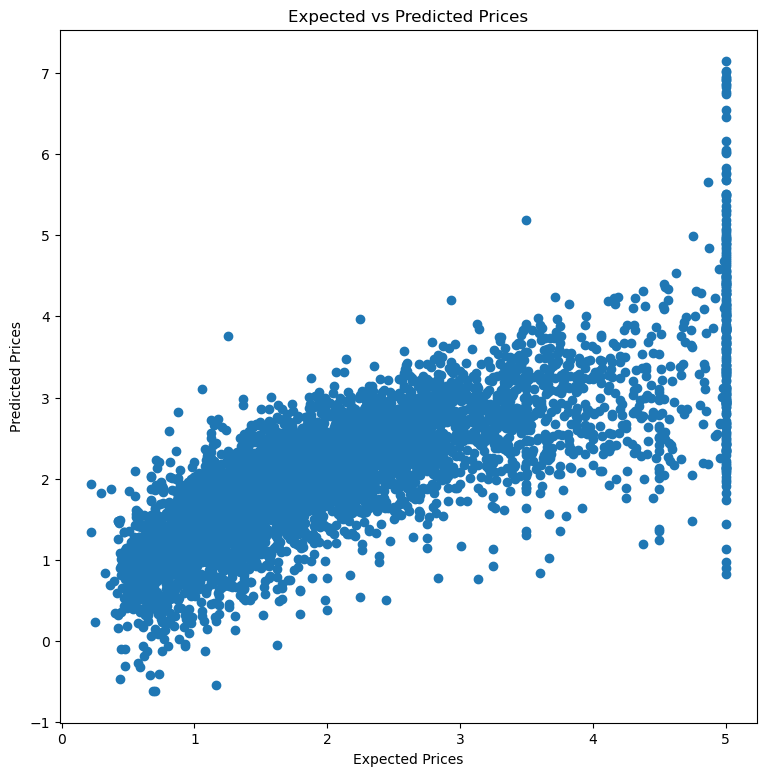

In [21]:
fig,axes = plt.subplots(1,1, figsize=(9,9))
axes.scatter(california_housing_target_test,predicted_median_house_prices)
plt.xlabel('Expected Prices')
plt.ylabel('Predicted Prices')
plt.title('Expected vs Predicted Prices')

# Reread the starting from page 85 just to make sure I understand the messages that's being conveyed to me ✅

In [22]:
#Create synthetic regression dataset of X, Y values
from sklearn.datasets import make_regression
SyntheticX,SyntheticY = make_regression( #use make_regression to generate fake data (y=mx+b+noise) (y = target values, m=slope,x=feature values,noise=random noise)
    n_samples=50, #50 X values & 50 Y values
    n_features = 1, #Each observation only has one predictor (for every x value there's only one y value)
    noise=35.0,#Adds random noise
    random_state=17 #The same random dataset is produced everytime I run the code (important for reproducible experiments!)
)
x_scaler = MinMaxScaler() #Creates an object that will normalize values between 0 and 1!
x_scaler.fit(SyntheticX.reshape(-1,1)) #Fitting the scaler to data. Sometimes 'make_regression' makes arrays horizontal but sklearn expects arrays to be vertical (50 rows, 1 Column NOT 50 Columns and 1 Row)
#Fit learns the minimum and maxium values of X and stores those values interanlly
SyntheticX = x_scaler.transform(SyntheticX.reshape(-1,1)) #Now the scaler applies the normalization, scaled X between 0 and 1
y_scaler = MinMaxScaler() #Creates an object that will normalize target values between 0 and 1!
y_scaler.fit(SyntheticY.reshape(-1,1))#Fitting scaler to learn min and max values of Y and reshaping
SyntheticY = y_scaler.transform(SyntheticY.reshape(-1,1)) #Now the scaler applies the normalization, scaled Y between 0 and 1

In [23]:
#If fit_intercept = True, then regression line does NOT have to pass through (0,0)
#If fit_intercept = False, then regression line MUST pass through (0,0)

Text(0, 0.5, 'Y')

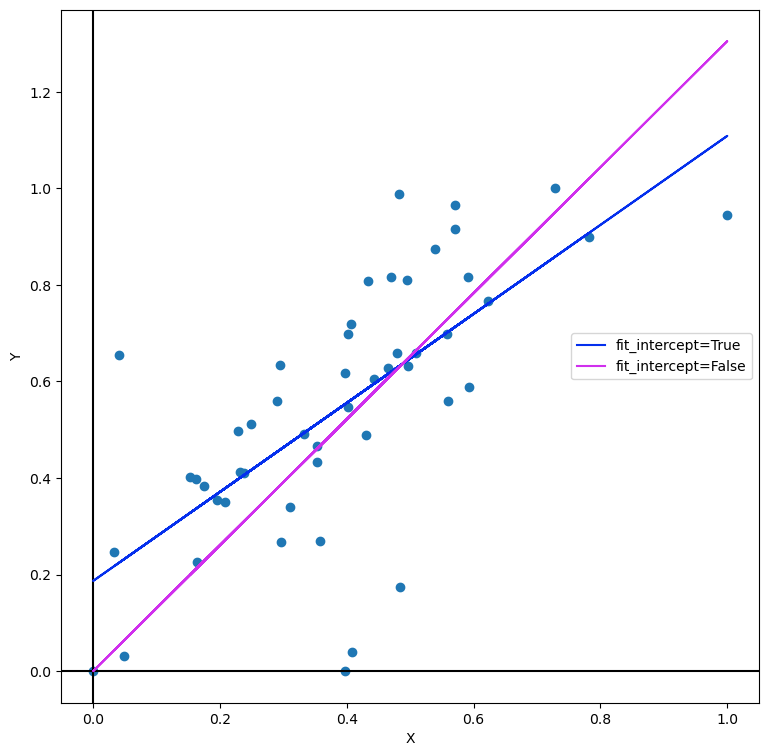

In [24]:
linear_regression_model_synthetic1 = LinearRegression(fit_intercept=True) #linear regression model is created with a fit_intercept of True (y=mx+b)[b=intercept, m=slope(coefficient)]
#Regression LINE IS ALLOWED TO START ABOVE OR BELOW ZERO!!
linear_regression_model_synthetic1.fit(SyntheticX,SyntheticY) #The model is trained (calculates best slope and intercept so that the predicted line MINIMIZES squared error between predictions and the real data)
linear_regression_model_synthetic2 = LinearRegression(fit_intercept=False) #linear regression model is created with a fit_intercept of False(y=mx)
#Regression line has to pass through (0,0)
linear_regression_model_synthetic2.fit(SyntheticX,SyntheticY)
c1 = linear_regression_model_synthetic1.coef_ #This give the slope of the regression line
i1 = linear_regression_model_synthetic1.intercept_ #Extracting the intercept
YPredicted1 = np.dot(SyntheticX,c1) + i1 #Predicting the Y values manually
c2 = linear_regression_model_synthetic2.coef_ #This give the slope of the regression line
i2 = linear_regression_model_synthetic2.intercept_ #Extracting the intercept (but since the fit_intercept=False then the value will always be equal to zero)
YPredicted2 = np.dot(SyntheticX,c2) + i2 

#Now lets create a scatte plot and overlay the two regression models with each other
fig,ax = plt.subplots(1,1,figsize=(9,9))
ax.axhline(y=0, color='k') #Draw a vertical line at exactly zero
ax.axvline(x=0,color='k') #Draw a horizontal line at exactly zero
#Now we have both axes displayed
ax.scatter(SyntheticX,SyntheticY) #Plotting the actual dataset
ax.plot(SyntheticX,YPredicted1,color='#042fed',label='fit_intercept=True') #Plotting model1
ax.plot(SyntheticX,YPredicted2,color='#d02fed',label='fit_intercept=False') #Plotting model2
plt.legend()
ax.set_xlabel('X')
ax.set_ylabel('Y')

# Support Vector Machines

In [25]:
diabetes_file = 'C:/Users/deanc/Documents/Datasets/Diabetes/diabetes.csv'
df_diabetes = pd.read_csv(diabetes_file)
df_diabetes_target = df_diabetes.loc[:,['Outcome']]
df_diabetes_features = df_diabetes.drop(['Outcome'],axis=1)
#normalize the attributes
diabetes_scaler = MinMaxScaler()
diabetes_scaler.fit(df_diabetes_features)
nd_diabetes_features = diabetes_scaler.transform(df_diabetes_features)
df_diabetes_normalized = pd.DataFrame(data=nd_diabetes_features, columns=df_diabetes_features.columns)

In [26]:
#Create test and training sets
df_diabetes_split = train_test_split(
    df_diabetes_normalized,
    df_diabetes_target,
    test_size =0.25,
    random_state=17
)
df_diabetes_features_train = df_diabetes_split[0]
df_diabetes_features_test = df_diabetes_split[1]
df_diabetes_target_train = df_diabetes_split[2]
df_diabetes_target_test = df_diabetes_split[3]

In [27]:
svc_model = SVC(kernel='linear', C=1)
svc_model.fit(df_diabetes_features_train,df_diabetes_target_train)
#Use the SVC model to create predictions on the test set.
predicted_diabetes = svc_model.predict(df_diabetes_features_test)

C:\Users\deanc\anaconda3\envs\AWS_ML_Book\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [28]:
print(predicted_diabetes)

[0 1 0 0 0 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0
 0 0 0 1 1 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 1 0
 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 0 0 1 0 1 0 1
 0 0 0 0 1 0 1]


In [29]:
from sklearn.datasets import make_classification
Synthetic_BinaryClassX, Synthetic_BinaryClassY = make_classification(
    n_samples = 50,
    n_features=2,
    n_redundant=0,
    n_classes=2
)

#Scale synthetic dataset from -3 to 3
scaler = MinMaxScaler(feature_range=(-3,3))
scaler.fit(Synthetic_BinaryClassX)
Synthetic_BinaryClassX = scaler.transform(Synthetic_BinaryClassX)

In [30]:
svc_model_linear = SVC(kernel='linear', C=1,gamma='auto')
svc_model_polynomial2 = SVC(kernel='poly', degree=2,C=1,gamma='auto')
svc_model_polynomial15 = SVC(kernel='poly',degree=15,C=1,gamma='auto')
svc_model_rbf = SVC(kernel='rbf',C=1,gamma='auto')
svc_model_linear.fit(Synthetic_BinaryClassX,Synthetic_BinaryClassY)
svc_model_polynomial2.fit(Synthetic_BinaryClassX,Synthetic_BinaryClassY)
svc_model_polynomial15.fit(Synthetic_BinaryClassX,Synthetic_BinaryClassY)
svc_model_rbf.fit(Synthetic_BinaryClassX,Synthetic_BinaryClassY)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Text(0.5, 1.0, 'RBF Kernel')

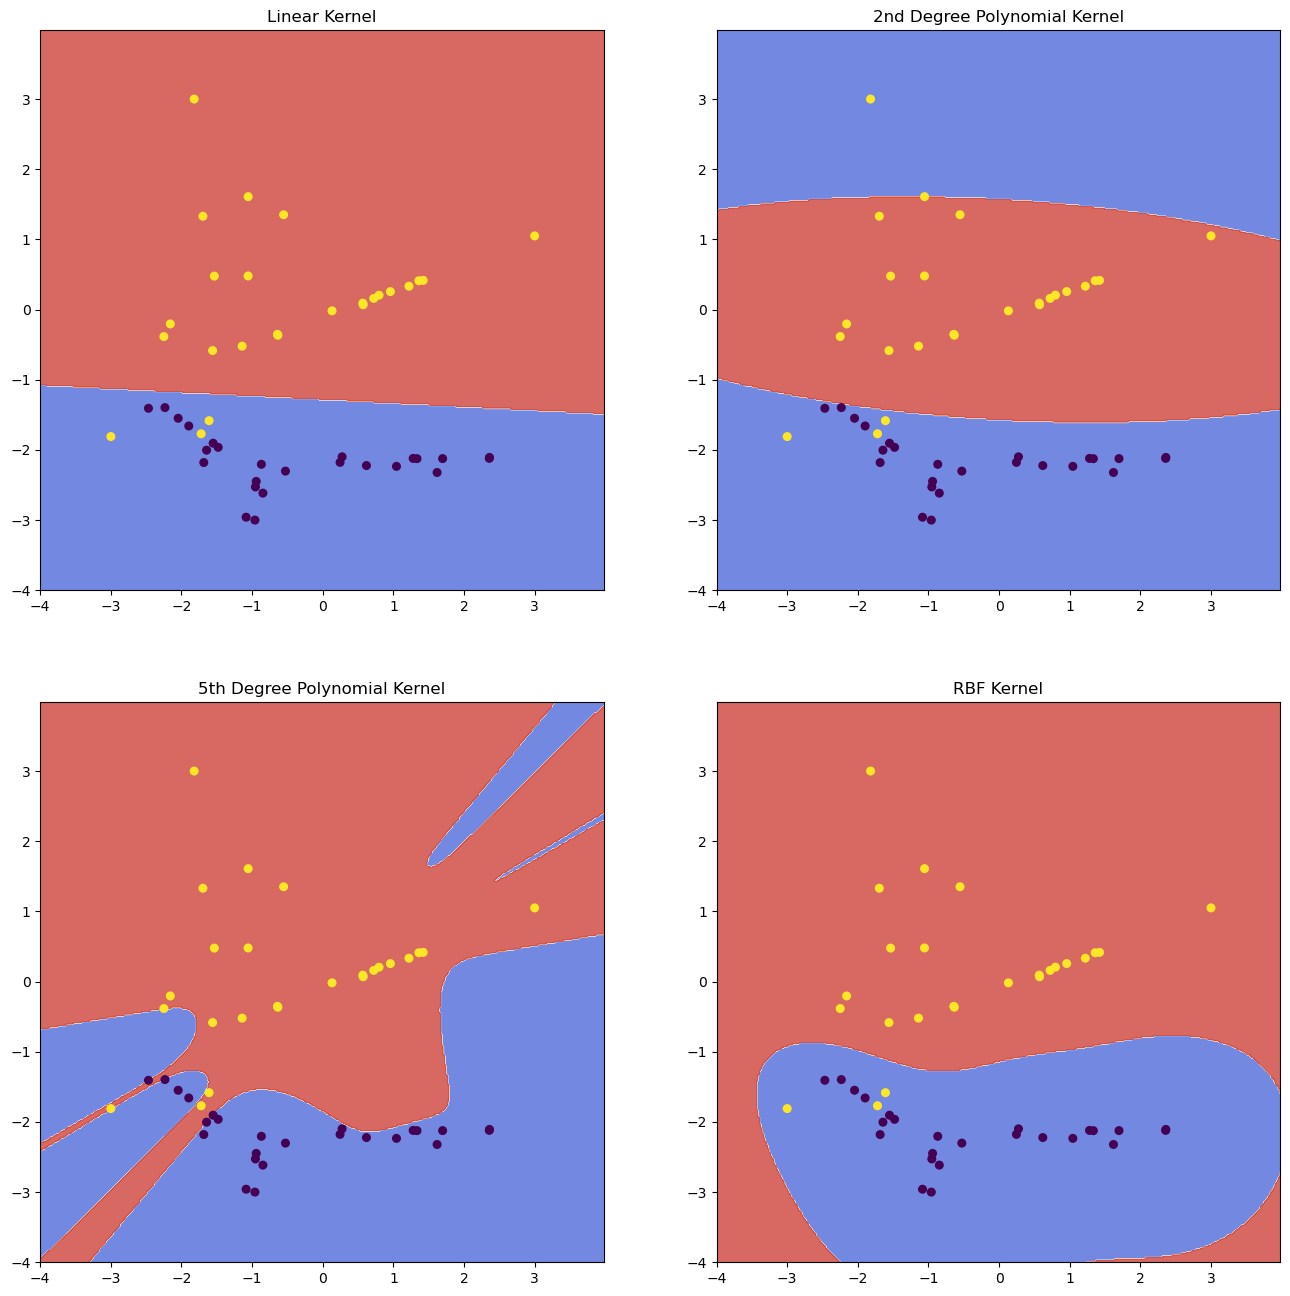

In [31]:
def plot_contours(ax, clf, xx, yy, **params):
    """Plot the decision boundaries for a classifier."""
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out


def make_meshgrid(x, y, h=0.2):
    """Create a mesh of points to plot in."""
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy


# pick our 2 features X0 and X1
X0 = Synthetic_BinaryClassX[:, 0]
X1 = Synthetic_BinaryClassX[:, 1]

xx, yy = make_meshgrid(X0, X1, 0.02)

fig, axes = plt.subplots(2, 2, figsize=(16,16))

plot_contours(axes[0,0], svc_model_linear, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
axes[0,0].scatter(X0, X1, s=30, c=Synthetic_BinaryClassY)
axes[0,0].set_xlim(xx.min(), xx.max())
axes[0,0].set_ylim(yy.min(), yy.max())
axes[0,0].set_title('Linear Kernel')

#Plot 2nd degree polynomial
plot_contours(axes[0,1], svc_model_polynomial2, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
axes[0,1].scatter(X0, X1, s=30, c=Synthetic_BinaryClassY)
axes[0,1].set_xlim(xx.min(), xx.max())
axes[0,1].set_ylim(yy.min(), yy.max())
axes[0,1].set_title('2nd Degree Polynomial Kernel')

#plot 15 degree polynomial kernel
plot_contours(axes[1,0], svc_model_polynomial15, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
axes[1,0].scatter(X0, X1, s=30, c=Synthetic_BinaryClassY)
axes[1,0].set_xlim(xx.min(), xx.max())
axes[1,0].set_ylim(yy.min(), yy.max())
axes[1,0].set_title('5th Degree Polynomial Kernel')

#plot RBF kernel
plot_contours(axes[1,1], svc_model_rbf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
axes[1,1].scatter(X0, X1, s=30, c=Synthetic_BinaryClassY)
axes[1,1].set_xlim(xx.min(), xx.max())
axes[1,1].set_ylim(yy.min(), yy.max())
axes[1,1].set_title('RBF Kernel')

In [32]:
#Train a linear model on the California house price dataset
#svr_model = SVR(kernel='linear', C=1.5, gamma='auto', epsilon=1.5)
#svr_model.fit(california_housing_features_train,california_housing_target_train.values.ravel())
#Use SVR model to create predictions on the test set.
#svr_predicited_prices = svr_model.predict(california_housing_features_test)

#Create a scatter plot of predicted vs expected values
#fig,axes = plt.subplots(figsize=(10,10))
#axes.scatter(california_housing_target_test,svr_predicited_prices)
#axes.set_xlabel('Expected Prices')
#axes.set_ylabel('Predicted Prices')
#axes.set_title('Expected vs Predicted Prices')
#plt.show()

# Model is taking more than 10min to run so I am not going to run it right now

# Logistic Regression AKA The Sigmoid Function used for classification!

In [41]:
#We'll use the Pima Indianas Database
#train a logistic model on the diabetes data
logistic_regression_model = LogisticRegression(
    l1_ratio=0,
    fit_intercept=True,
    solver='liblinear'
)
logistic_regression_model.fit(df_diabetes_features_train,df_diabetes_target_train.values.ravel())
#use the model to create predictions on the test set, with a theshold of 0.5
logistic_regression_predictions = logistic_regression_model.predict(df_diabetes_features_test)
print(logistic_regression_predictions)

[0 1 0 0 0 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 1 0
 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1
 0 0 0 0 1 0 0]


In [46]:
#Access class-wise probabilities
logistic_regression_probabilities = (
    logistic_regression_model.predict_proba(df_diabetes_features_test)
)
print(logistic_regression_probabilities)

[[0.85694005 0.14305995]
 [0.37165061 0.62834939]
 [0.73695232 0.26304768]
 [0.880803   0.119197  ]
 [0.70516787 0.29483213]
 [0.55565012 0.44434988]
 [0.79759532 0.20240468]
 [0.41521706 0.58478294]
 [0.40539318 0.59460682]
 [0.45727931 0.54272069]
 [0.36492866 0.63507134]
 [0.37971139 0.62028861]
 [0.77569099 0.22430901]
 [0.58385946 0.41614054]
 [0.76774197 0.23225803]
 [0.81174178 0.18825822]
 [0.48426592 0.51573408]
 [0.81058485 0.18941515]
 [0.63841705 0.36158295]
 [0.64774812 0.35225188]
 [0.46058037 0.53941963]
 [0.73207878 0.26792122]
 [0.86982262 0.13017738]
 [0.26364759 0.73635241]
 [0.62668563 0.37331437]
 [0.77056865 0.22943135]
 [0.28582594 0.71417406]
 [0.91957668 0.08042332]
 [0.49911929 0.50088071]
 [0.67216545 0.32783455]
 [0.37647145 0.62352855]
 [0.67616386 0.32383614]
 [0.83388024 0.16611976]
 [0.83247743 0.16752257]
 [0.70948957 0.29051043]
 [0.88923481 0.11076519]
 [0.36769165 0.63230835]
 [0.64198316 0.35801684]
 [0.86469324 0.13530676]
 [0.59910864 0.40089136]


In [51]:
#implement custom thresholding logic
dfProbabilities = pd.DataFrame(logistic_regression_probabilities[:,0])
predictions = dfProbabilities.map(lambda x: 0 if x > 0.8 else 1)

In [52]:
print(predictions.values.ravel())

[0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1 0 0 1 0 1
 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 0
 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0 0 0 0 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0
 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 1
 1 1 1 1 0 1 0 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1]


In [53]:
print(logistic_regression_model.coef_),print(logistic_regression_model.intercept_)

[[ 1.48972976  3.4891602  -0.7344297  -0.07461329  0.16776565  1.81409369
   1.39383873  1.03554067]]
[-4.06714158]


(None, None)

In [54]:
print("Intercept:",logistic_regression_model.intercept_)

Intercept: [-4.06714158]


# Using Logistic Regression for Multiclass classification! The OVR method vs the OVO method!


# The OVR method creates N models for N classes. The final class output is decided by the class that had the highest probability

In [59]:
#We'll use the iris dataset that we always used the test_train_split function on. 
#implement multi-class classification using OVR approach and logistic Regression
logit_model = LogisticRegression(
    l1_ratio=0,
    fit_intercept=True,
    solver='liblinear'
)
ovr_logit_model = OneVsRestClassifier(logit_model)
ovr_logit_model.fit(df_iris_features_train,df_iris_target_train.values.ravel())
ovr_logit_predictions = ovr_logit_model.predict(df_iris_features_test)

In [60]:
print(ovr_logit_predictions)

[0 0 0 0 0 0 1 1 1 1 1 2 2 2 2]


In [61]:
#Now let's access the class-wise probabilities
ovr_logit_probs = ovr_logit_model.predict_proba(df_iris_features_test)
print(ovr_logit_probs)

[[8.16223206e-01 1.83693360e-01 8.34342032e-05]
 [8.88673400e-01 1.11309305e-01 1.72951685e-05]
 [7.89190254e-01 2.10771541e-01 3.82054542e-05]
 [8.26999724e-01 1.72898499e-01 1.01777008e-04]
 [8.44222672e-01 1.55758619e-01 1.87092113e-05]
 [9.10360264e-01 8.95477488e-02 9.19874940e-05]
 [1.23956870e-02 6.83506949e-01 3.04097364e-01]
 [5.16563341e-02 8.26994443e-01 1.21349223e-01]
 [6.25096268e-02 8.02714724e-01 1.34775649e-01]
 [5.74520612e-02 6.62936701e-01 2.79611238e-01]
 [2.30158992e-02 6.52237506e-01 3.24746595e-01]
 [8.06262860e-04 2.41268703e-01 7.57925034e-01]
 [2.41507610e-03 4.92816376e-01 5.04768548e-01]
 [1.39419471e-03 2.95579341e-01 7.03026464e-01]
 [9.59818933e-04 2.95716381e-01 7.03323800e-01]]


# Now we are getting into the softmax function (multiclass classification)!

In [66]:
#Implement multiclass classification using softmax (multinomial regression classifier)
softmax_logit_model = LogisticRegression(
    fit_intercept=True,
    solver='lbfgs',
)
softmax_logit_model.fit(
    df_iris_features_train,
    df_iris_target_train.values.ravel()
)

#now we use the model to create predictions about the set
softmax_logit_predict = softmax_logit_model.predict(df_iris_features_test)
print(softmax_logit_predict)

[0 0 0 0 0 0 1 1 1 1 1 2 2 2 2]


# Decision Trees

In [70]:
dtree_model = DecisionTreeClassifier(max_depth=4)
dtree_model.fit(df_iris_features_train,df_iris_target_train.values.ravel())
#Now we create predictions
dtree_model_predictions =  dtree_model.predict(df_iris_features_test)
print(dtree_model_predictions)

[0 0 0 0 0 0 1 1 1 1 1 2 1 2 2]


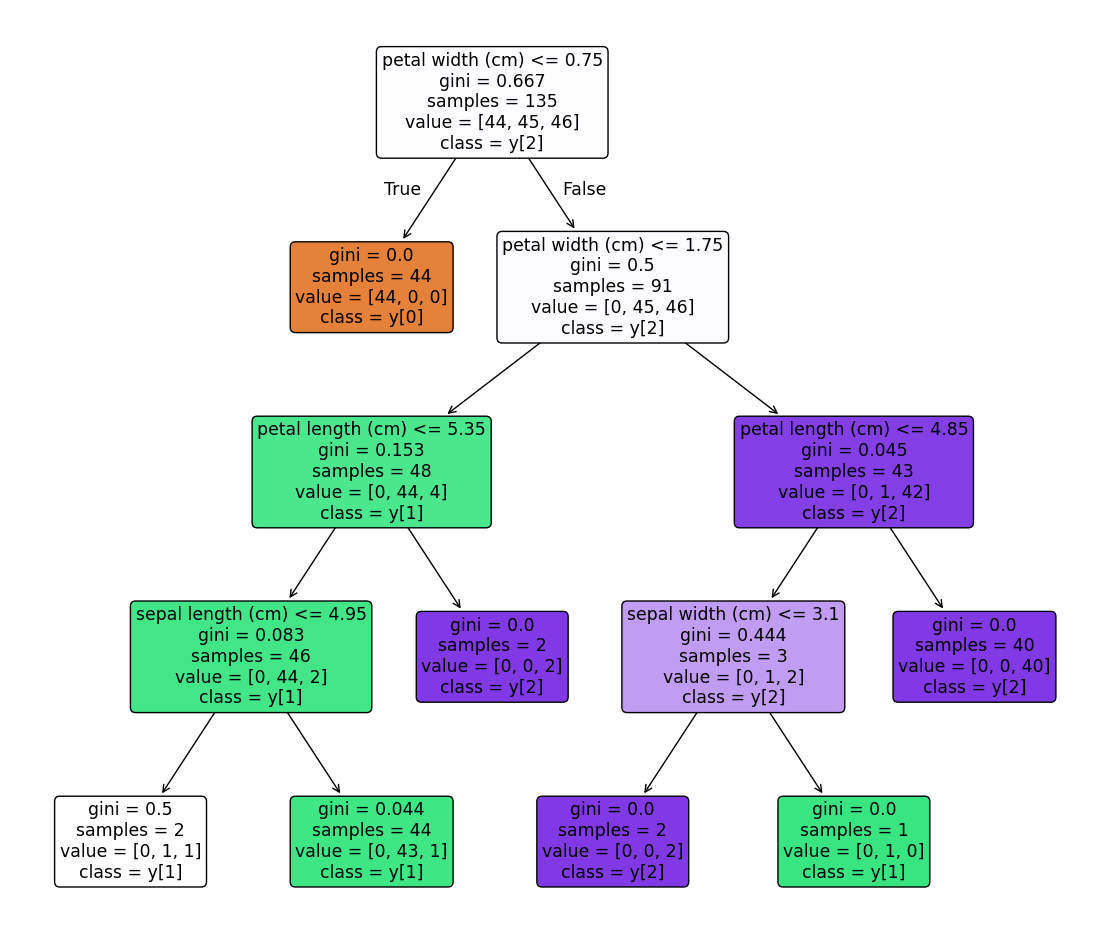

In [83]:
plt.figure(figsize=(14,12))
tree.plot_tree(
    dtree_model,
    filled=True,
    rounded=True,
    feature_names=df_iris_features.columns,
    class_names=True
)
plt.show()

Gini regers to Gini Impurity

How 'mixed' classes are at a node

Low gini ~ Mostly one calss

High gini ~ Node is mixed with many classes

In [88]:
#Create a decision tree based regressor on the California housing market
dtree_reg_model = DecisionTreeRegressor(max_depth=4)
dtree_reg_model.fit(california_housing_features_train,california_housing_target_train.values.ravel())
#Now we use the model to create predictions on test set
dtree_reg_predictions = dtree_reg_model.predict(california_housing_features_test)

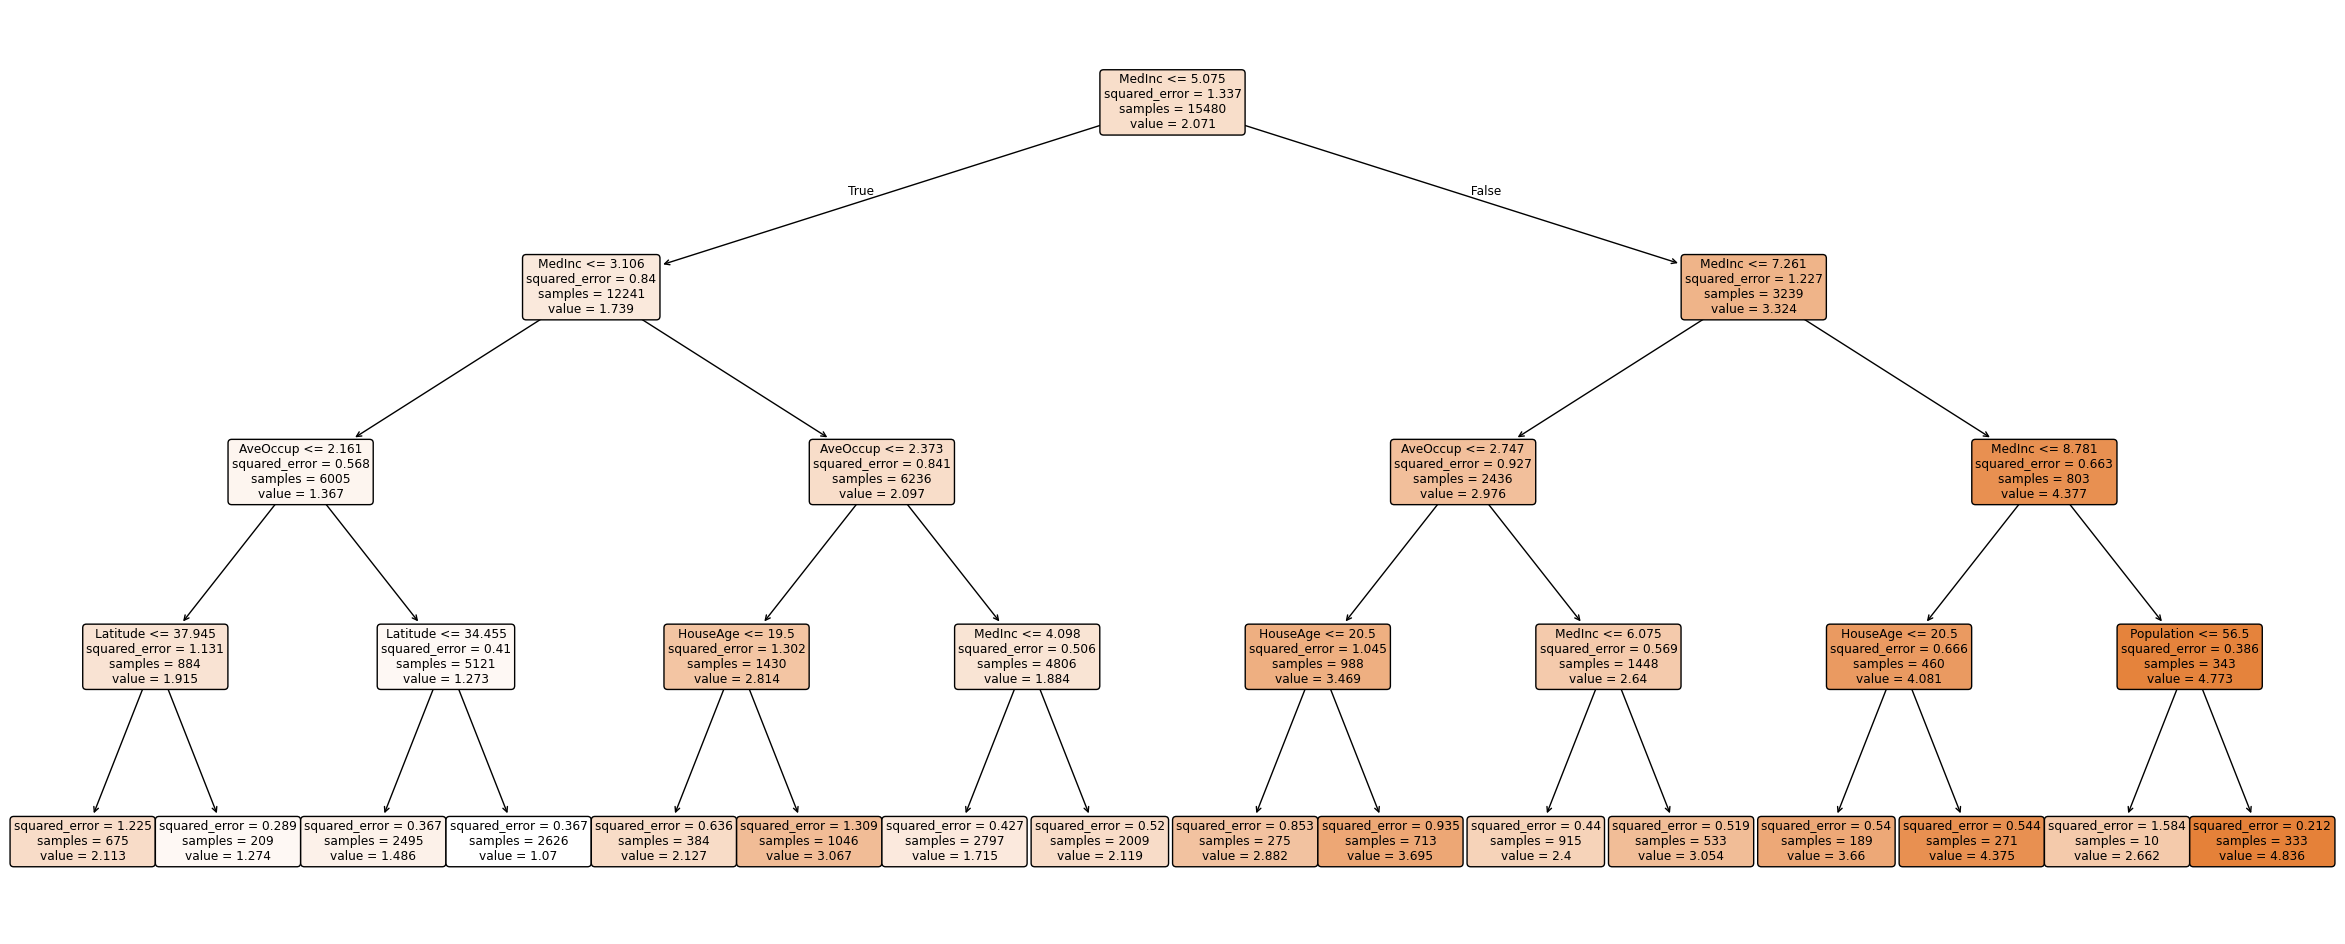

In [92]:
plt.figure(figsize=(30,12))
tree.plot_tree(
    dtree_reg_model,
    filled=True,
    rounded=True,
    feature_names=california_housing_features.columns,
    class_names=True
)
plt.show()